In [37]:
%load_ext autoreload
%autoreload 2

from models import U_Net, AttU_Net
from train import train_2D, test_2D, test_3D
from utils import compare_predictions_ground_truth, prepare_data, graph, predict_volume
from torch.utils.data import TensorDataset, DataLoader
import nibabel as nib

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [45]:
(X_train_tensor,
X_validation_tensor,
X_test_tensor,
y_train_tensor,
y_validation_tensor,
y_test_tensor,
X_test_3D,
y_test_3D) = prepare_data(train_size = 14, validation_size=2, rand = True, data_path="data")

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

validation_dataset = TensorDataset(X_validation_tensor, y_validation_tensor)
validation_loader = DataLoader(validation_dataset, batch_size=4, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=True)

X_train.shape :  (459, 1, 256, 256)
X_validation.shape :  (63, 1, 256, 256)
X_test.shape :  (125, 1, 256, 256)


In [ ]:
train_loss,validation_losses = train_2D(
    model=AttU_Net(1, 5),
    train_loader=train_loader,
    validation_loader=validation_loader,
    name ="attU_Net_10epochs",
    num_epochs=10,
    lr=1e-4,
    max_no_upgrade=100
)

In [62]:
test_loss,dice_classes = test_2D(
    model=AttU_Net(1,5),
    test_loader=test_loader,
    name ="models/attU_Net_weights100"
)

Loss on test dataset: 0.1405
Dice per class on test dataset: [0.99642685 0.89546959 0.56651685 0.5992114  0.68888209]


In [61]:
test_3D(AttU_Net(1,5), X_test_3D, y_test_3D, "models/attU_Net_weights100")

tensor([0.9967, 0.9367, 0.7073, 0.7162, 0.8825])

In [7]:
graph(train_loss,validation_losses)

NameError: name 'train_loss' is not defined

In [61]:
model = AttU_Net(1,5)
import torch
model.load_state_dict(torch.load("models/attU_Net_weights10.pth"))

<All keys matched successfully>

In [64]:
print(X_test_3D[0].shape)
out = model.forward_volume(X_test_3D[0])

print(out.shape)

torch.Size([30, 256, 256])
torch.Size([30, 5, 256, 256])


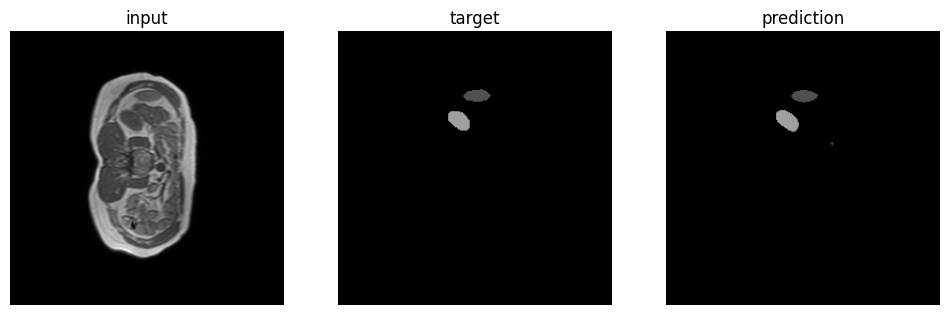

IntSlider(value=11, description='Slice', max=34)

In [73]:
compare_predictions_ground_truth(AttU_Net(1,5), "models/attU_Net_weights100.pth", "data/MR-dataset/01-T1DUALin-src.nii.gz", "data/MR-dataset/01-T1DUAL-mask.nii.gz")

In [71]:
nifti_out, volume = predict_volume(AttU_Net(1,5), "models/attU_Net_weights100.pth","data/MR-dataset/01-T1DUALin-src.nii.gz")

<class 'numpy.ndarray'>
(35, 256, 256)


In [9]:
save_path = "reconstructed_volumes/predicted_mask_01-T1DUAL_Att_U_Net.nii.gz"
nib.save(nifti_out, save_path)

In [22]:
from losses import dice_per_class_3D
import torch
img = nib.load("data/MR-dataset/01-T1DUAL-mask.nii.gz")
data = img.get_fdata()

data = torch.tensor(data, dtype=torch.float32)
volume = torch.tensor(volume, dtype=torch.float32)

data = data.permute(2,0,1)
print(volume.shape)
volume = volume.permute(2,0,1)

unique_vals = torch.unique(data)


# Appliquer le mapping
mapped = torch.bucketize(data, unique_vals)

print(mapped.shape)
print(volume.shape)

torch.Size([256, 256, 35])
torch.Size([35, 256, 256])
torch.Size([35, 256, 256])


In [23]:
dice = dice_per_class_3D(volume, mapped, 5)

print(dice)

tensor([0.0535, 0.9860, 0.2654, 0.4173, 0.2606])
